In [1]:
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator
from transformers import OwlViTProcessor, OwlViTForObjectDetection
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import requests
import colorsys
import torch
import cv2
import os 

try:
    from local_config import images_path, SAM_CHECKPOINT, MODEL_TYPE
except ImportError:
    images_path = r"D:\Работа\Карандеев\Видеорегистратор\testing_video_results2\\"
    SAM_CHECKPOINT = r"C:\Users\romak\segment-anything\weights/sam_vit_b_01ec64.pth"
    MODEL_TYPE = "vit_b"

processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")
model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32")

sam = sam_model_registry[MODEL_TYPE](checkpoint=SAM_CHECKPOINT)
sam_predictor = SamPredictor(sam)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
sam.to(device)

# Перечисление необходимых классов для поиска
texts = ["car", "truck", "road sign", "tree", "person",
    
    # Фонарные столбы
    "lamp post", 
    "street light", 
    "light pole",     
         
    # Другие столбы
    "pole", 
    "utility pole", 
    "electric pole", 
    "telephone pole", 
         
    # Основные теги разметки
    "road markings",
    "lane markings",
    "street markings",
    "road lines",
    "traffic lines",
    "pedestrian crossing", 
    "road stripe",
    "traffic lane",
    "lane marking",
    "road line",
    "solid white line",
    "dashed white line",
    "yellow road line",
    "double yellow line",
    "lane divider",
    "center line",
    "crosswalk",
    "zebra crossing",
    "stop line",
    "turn arrow on road",
    "bicycle lane marking",
    "bus lane marking",

    # Дополнительные теги разметки
    "road sign painted on asphalt",
    "traffic symbols on road",
    "no parking marking",
    "speed limit painted on road",
    "chevron road marking",
    "merge arrows on road",
    "intersection marking",
    "pedestrian marking",
        
    # Основные дефекты покрытия
    "crack in the road",
    "asphalt crack",
    "longitudinal crack",
    "transverse crack",
    "alligator crack",
    "block crack",
    "edge crack",
    "pothole",
    "shallow pothole",
    "deep pothole",
    "sinkhole",
    "rutting",
    "road rut",
    "uneven road surface",
    "bumpy road",
    "road depression",
    "surface wear",
    "road erosion",
    "faded road surface",
    "delamination of asphalt",
    "loose gravel on road",
    "missing asphalt patch",
    "repaired patch",
    "rough surface",
         
    # Связанные с инфраструктурой дефекты
    "collapsed manhole",
    "open manhole",
    "broken drain grate",
    "sunken manhole",
    "raised utility cover",
    "damaged curb",
    "eroded road shoulder",
    "damaged speed bump",
    "damaged pedestrian crossing",
        
    # Нарушения в разметке и временные проблемы
    "faded road marking",
    "damaged crosswalk marking",
    "erased lane line",
    "temporary patch on road",
    "temporary repair",
    "construction damage",
    "roadwork trace"
    ]

text_count = [0]*len(texts)
id2label = {i: name for i, name in enumerate(texts)}  
all_results = []
all_results_with_masks = []  

for i in range(len(os.listdir(images_path)[:3])):
    tmp = f'frame_{i}.0.jpg' # Название изображений
    print(tmp)
    image_path = images_path + tmp
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)
    sam_predictor.set_image(image_np)


    inputs = processor(text=texts, images=image, return_tensors="pt").to(device)
    outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]]).to(device)
    results = processor.post_process_object_detection(outputs=outputs, target_sizes=target_sizes)[0]

    threshold = 0.15 # Порог отсечения по уроню ыверенности модели
    filtered = [(score, label, box) for score, label, 
                box in zip(results["scores"], results["labels"], results["boxes"]) if score > threshold]   

    if len(filtered) > 0: 
        print(i, f"Objects with score > {threshold}: {len(filtered)}")
        masks_list = []
        for score, label, box in filtered:
            label_id = label.item()
            text_count[label_id] += 1
            label_name = id2label.get(label_id, f"LABEL_{label_id}")
            box_coords = box.detach().cpu().numpy()
            print(f"Label: {label_name}, Score: {score:.4f}, Box: {box.tolist()}")
            all_results.append([tmp, label_name, f"{score:.4f}", box.tolist()])

             # Сегментация с помощью SAM
            try:
                x1, y1, x2, y2 = box_coords
                input_box = np.array([x1, y1, x2, y2])
                masks, scores_sam, _ = sam_predictor.predict(
                    point_coords=None,
                    point_labels=None,
                    box=input_box[None, :],
                    multimask_output=True
                )
                
                # Выбираем лучшую маску по score
                best_mask_idx = np.argmax(scores_sam)
                mask = masks[best_mask_idx]
                mask_score = scores_sam[best_mask_idx]
                masks_list.append((mask, label_name, score, box_coords))    
                
                all_results_with_masks.append([
                    tmp,                    # 0: имя файла
                    label_name,             # 1: название класса
                    float(score),           # 2: score OWL-ViT как число
                    box_coords.tolist(),    # 3: bbox координаты
                    mask,                   # 4: маска как numpy array
                    float(mask_score),      # 5: score SAM как число
                ])
                
            except Exception as e:
                print(f"Ошибка сегментации для {label_name}: {e}")
                all_results_with_masks.append([
                    tmp, label_name, float(score), box_coords.tolist(), 
                    None, None
                ])
                
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        ax1 = axes[0]
        ax1.imshow(image)
        ax1.set_title(f"Detected Objects (count: {len(filtered)})")
        for score, label, box in filtered:
            label_id = label.item()
            label_name = id2label.get(label_id, f"LABEL_{label_id}")
            box = box.detach().cpu().numpy()
            rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                     linewidth=2, edgecolor='r', facecolor='none')
            ax1.add_patch(rect)
            ax1.text(box[0], box[1], f"{label_name}: {score:.2f}", 
                    color='white', fontsize=8, backgroundcolor='red')
            
        ax2 = axes[1]
        ax2.imshow(image)
        ax2.set_title("Segmentation Masks")

        if masks_list:
            colored_mask = np.zeros((image_np.shape[0], image_np.shape[1], 3), dtype=np.uint8)
            for idx, (mask, label_name, score, box_coords) in enumerate(masks_list):
                hue = hash(label_name) % 360 / 360.0
                r, g, b = colorsys.hsv_to_rgb(hue, 0.7, 1.0)
                color = np.array([r, g, b]) * 255
                
                for c in range(3):
                    colored_mask[:, :, c] = np.where(
                        mask == 1,
                        color[c],
                        colored_mask[:, :, c]
                    )
                
                from skimage import measure
                contours = measure.find_contours(mask, 0.5)
                for contour in contours:
                    ax2.plot(contour[:, 1], contour[:, 0], linewidth=2, color='red')
                
                ax2.text(box_coords[0], box_coords[1], f"{label_name}: {score:.2f}", 
                        color='white', fontsize=8, backgroundcolor='black')
            
            ax2.imshow(colored_mask, alpha=0.5)
        
        plt.tight_layout()
        plt.show()
 

Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

Найдено объектов в кадре frame_1.0.jpg: 15

Объект 1: street light
  Score OWL-ViT: 0.2336
  BBox: [1114.357421875, 117.54076385498047, 1379.5511474609375, 1002.013916015625]
  Score SAM: 0.942

Объект 2: street light
  Score OWL-ViT: 0.1514
  BBox: [238.93701171875, 567.4445190429688, 346.3495178222656, 938.59521484375]
  Score SAM: 0.832

Объект 3: street light
  Score OWL-ViT: 0.1762
  BBox: [961.9622802734375, 693.525634765625, 1225.0885009765625, 913.4616088867188]
  Score SAM: 0.650

Объект 4: car
  Score OWL-ViT: 0.1563
  BBox: [366.2325134277344, 940.4827270507812, 567.331298828125, 1089.7872314453125]
  Score SAM: 0.939

Объект 5: car
  Score OWL-ViT: 0.1770
  BBox: [505.2919006347656, 946.1650390625, 788.8475952148438, 1131.0230712890625]
  Score SAM: 0.954

Объект 6: car
  Score OWL-ViT: 0.2952
  BBox: [906.2063598632812, 896.8921508789062, 1370.5677490234375, 1312.67724609375]
  Score SAM: 0.972

Объект 7: road line
  Score OWL-ViT: 0.1550
  BBox: [1339.0223388671875, 1060.

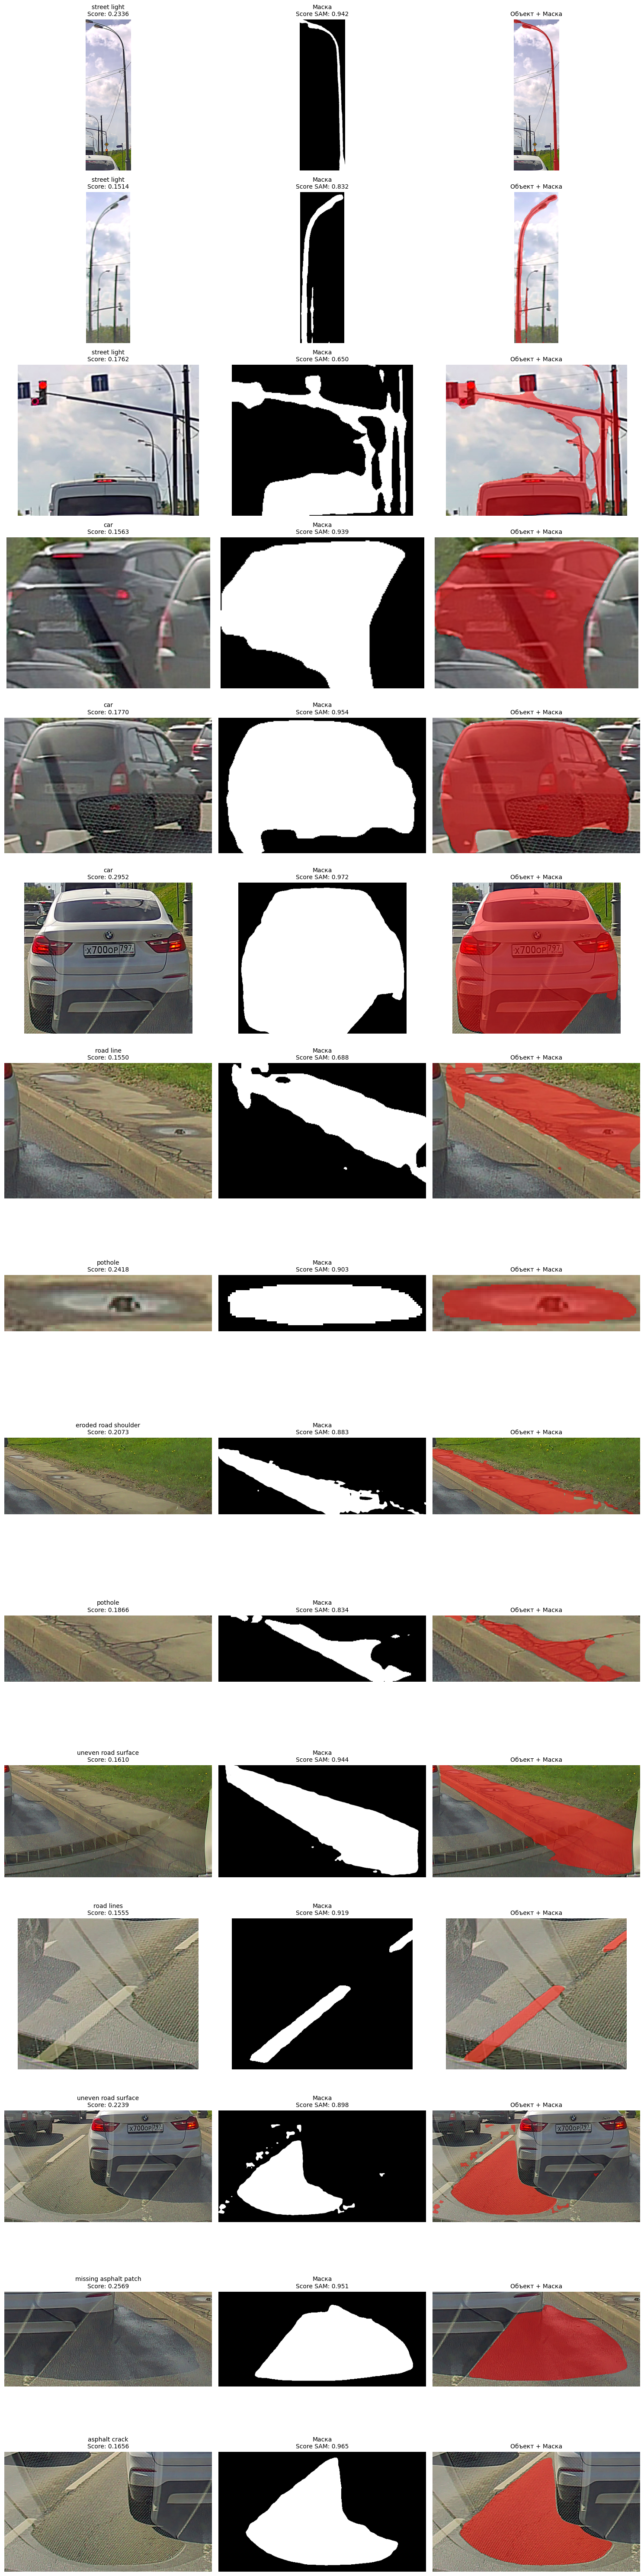

In [4]:
tmp = 'frame_1я.0.jpg'

objects_for_frame = [res for res in all_results_with_masks if res[0] == tmp]

if objects_for_frame:
    image_path = images_path + tmp
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)
    
    print(f"Найдено объектов в кадре {tmp}: {len(objects_for_frame)}")
    
    cols = 3
    rows = len(objects_for_frame)
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    for idx, obj_data in enumerate(objects_for_frame):
        filename, label_name, score, box_coords, mask, mask_score = obj_data
        
        print(f"\nОбъект {idx+1}: {label_name}")
        print(f"  Score OWL-ViT: {score:.4f}")
        print(f"  BBox: {box_coords}")
        
        if mask is not None:
            print(f"  Score SAM: {mask_score:.3f}")
            
            x1, y1, x2, y2 = [int(coord) for coord in box_coords]
            cropped_image = image_np[y1:y2, x1:x2]
            
            mask_cropped = mask[y1:y2, x1:x2]
            
            ax1 = axes[idx, 0]
            ax1.imshow(cropped_image)
            ax1.set_title(f"{label_name}\nScore: {score:.4f}", fontsize=10)
            ax1.axis('off')
            
            ax2 = axes[idx, 1]
            ax2.imshow(mask_cropped, cmap='gray')
            ax2.set_title(f"Маска\nScore SAM: {mask_score:.3f}", fontsize=10)
            ax2.axis('off')
            
            ax3 = axes[idx, 2]
            ax3.imshow(cropped_image)
            
            colored_mask = np.zeros((*mask_cropped.shape, 4))
            colored_mask[mask_cropped == 1] = [1, 0, 0, 0.5]  # Красный, 50% прозрачность
            
            ax3.imshow(colored_mask)
            ax3.set_title(f"Объект + Маска", fontsize=10)
            ax3.axis('off')
        else:
            print(f"  Маска не найдена")
            
            x1, y1, x2, y2 = [int(coord) for coord in box_coords]
            cropped_image = image_np[y1:y2, x1:x2]
            
            ax1 = axes[idx, 0]
            ax1.imshow(cropped_image)
            ax1.set_title(f"{label_name} (без маски)\nScore: {score:.4f}", fontsize=10)
            ax1.axis('off')
            
            axes[idx, 1].axis('off')
            axes[idx, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Для кадра {tmp} не найдено объектов в all_results_with_masks")